In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings 
warnings.filterwarnings("ignore")

In [4]:
from sklearn.datasets import load_iris

In [6]:
data = load_iris()

In [12]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [13]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [16]:
df = pd.DataFrame(data.data,columns=data.feature_names)

In [19]:
df["target"] = data.target

In [22]:
x = df.iloc[:,:-1]

In [24]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [27]:
y = df.iloc[:,-1]

In [28]:
# train test split 

In [29]:
from sklearn.model_selection import train_test_split

In [31]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=1)

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
dt = DecisionTreeClassifier(criterion="entropy")

In [39]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [41]:
from sklearn import tree

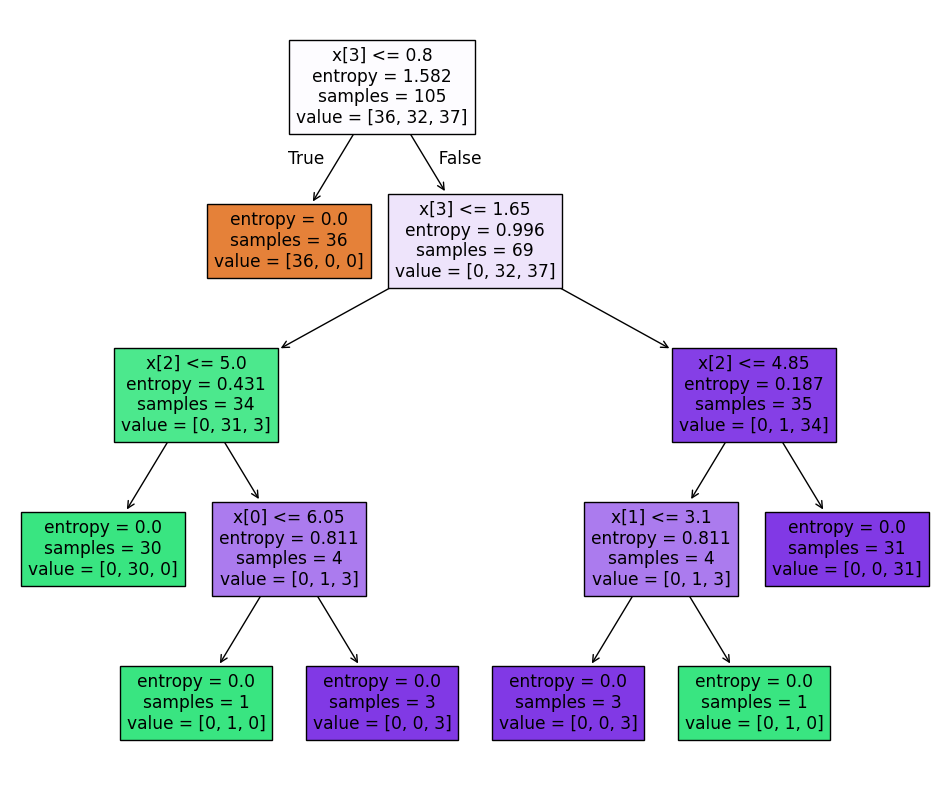

In [44]:
plt.figure(figsize=(12,10))
tree.plot_tree(dt,filled=True)
plt.show()

In [46]:
y_pred = dt.predict(x_test)

In [48]:
from sklearn.metrics import accuracy_score

In [50]:
accuracy_score(y_test,y_pred)

0.9555555555555556

In [51]:
# after making complete decision cut it to avoide decision tree 

In [56]:
dt2 = DecisionTreeClassifier(criterion="entropy",max_depth=2)

In [57]:
dt2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

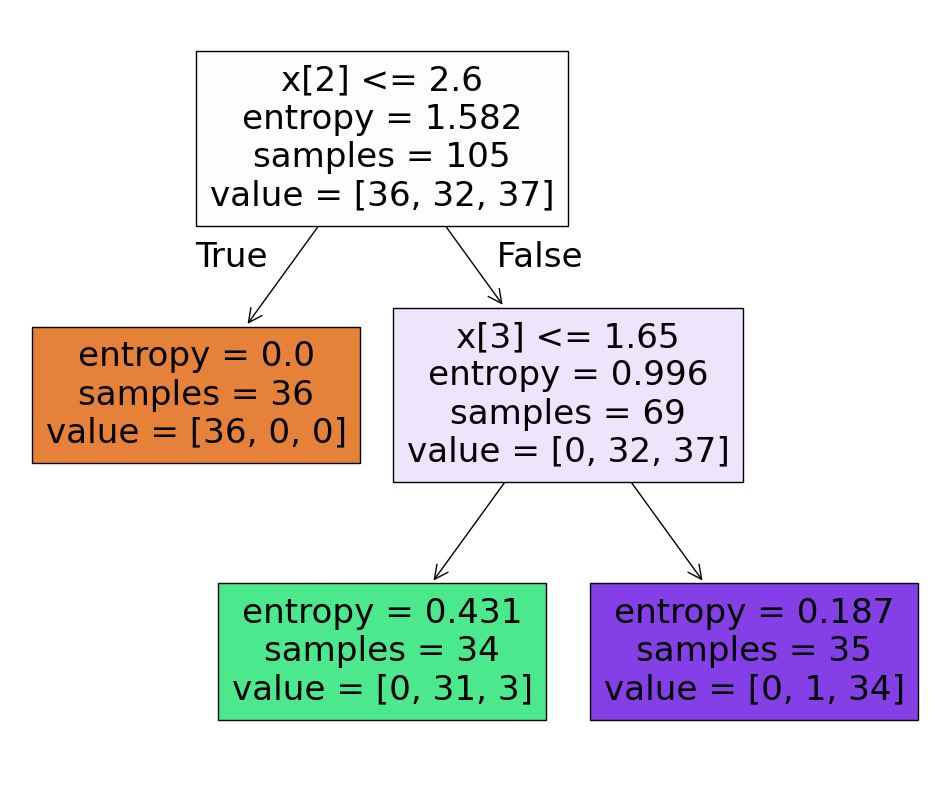

In [62]:
plt.figure(figsize=(12,10))
tree.plot_tree(dt2,filled=True)
plt.show()

In [64]:
y_pred = dt2.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)  # here the accuracy is same so preiously it is overfitting

0.9555555555555556

In [66]:
# now pre - prunning 

In [71]:
params = {"criterion" : ["gini","entropy"],"max_depth":[1,2,3,4,5,6,7,8,9]}

In [72]:
dt3 = DecisionTreeClassifier()

In [70]:
from sklearn.model_selection import GridSearchCV

In [ ]:
gs = GridSearchCV(dt3,param_grid=params,cv = 5)  # verbous meaning if we want the detail of the model training

In [76]:
gs.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9]})

In [77]:
gs.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [78]:
dt3 = DecisionTreeClassifier(criterion="gini",max_depth=3)

In [80]:
dt3

DecisionTreeClassifier(max_depth=3)

In [82]:
dt3.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

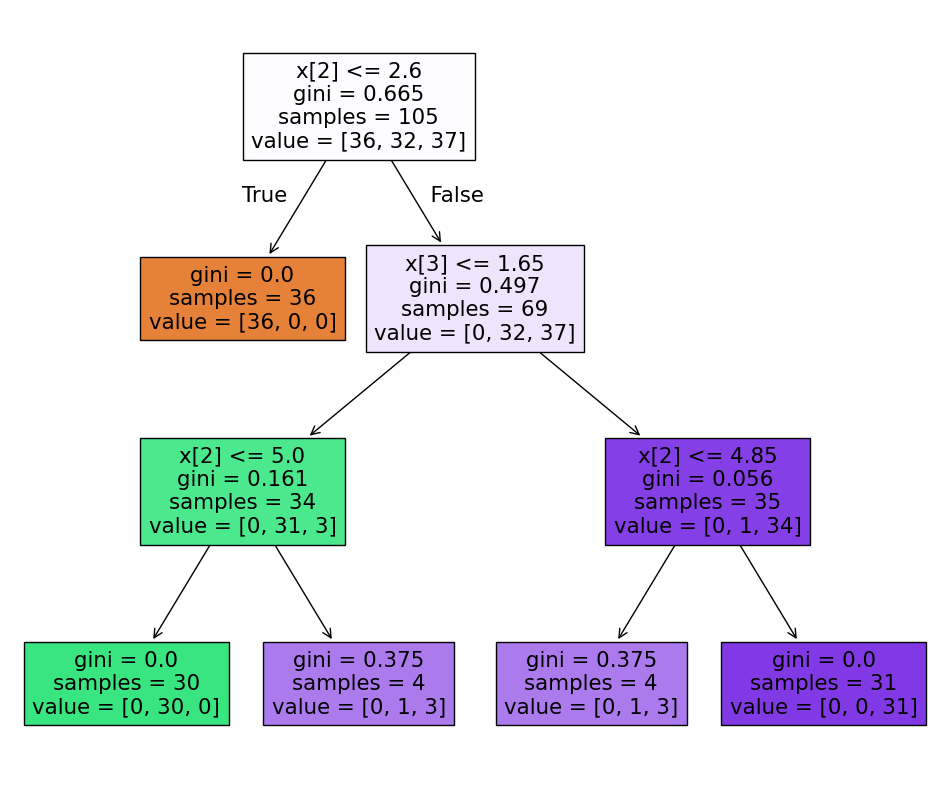

In [84]:
plt.figure(figsize=(12,10))
tree.plot_tree(dt3,filled=True)
plt.show()